# Eksplorasi Data Aksara Jawa (Hanacaraka)
**Tujuan:** Memahami distribusi, kualitas, dan karakteristik visual dataset sebelum training CNN.

Notebook ini harus dijalankan **setelah** `download_dataset.py` selesai dieksekusi.

```bash
python download_dataset.py               # GitHub only
python download_dataset.py --roboflow-key YOUR_KEY  # + Roboflow
```

In [2]:
import os
import warnings
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image
from tqdm.notebook import tqdm

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

DATASET_DIR = Path('dataset')
SPLITS      = ['train', 'val', 'test']
CLASSES = [
    'ha', 'na', 'ca', 'ra', 'ka',
    'da', 'ta', 'sa', 'wa', 'la',
    'pa', 'dha', 'ja', 'ya', 'nya',
    'ma', 'ga', 'ba', 'tha', 'nga',
]

# Folder output untuk semua gambar EDA — dibuat otomatis jika belum ada
EDA_OUT = Path('eda_results')
EDA_OUT.mkdir(parents=True, exist_ok=True)

# Sanity check
assert DATASET_DIR.exists(), (
    f"Dataset directory '{DATASET_DIR}' not found. "
    "Run download_dataset.py first."
)
print(f'Dataset directory  : {DATASET_DIR}')
print(f'EDA output folder  : {EDA_OUT.resolve()}')

Dataset directory  : dataset
EDA output folder  : C:\KULIAH\SEMESTER 4\PEMBELAJARAN MESIN\KlasifikasiHanacaraka\eda_results


## 1. Inventory: Hitung Semua Gambar

In [3]:
IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

def build_inventory(dataset_dir: Path) -> pd.DataFrame:
    """
    Walk dataset/train|val|test/<class>/*.jpg
    Return flat DataFrame with one row per image.
    """
    records = []
    for split in SPLITS:
        split_dir = dataset_dir / split
        if not split_dir.exists():
            continue
        for cls_dir in sorted(split_dir.iterdir()):
            if not cls_dir.is_dir():
                continue
            cls = cls_dir.name
            for img_path in cls_dir.iterdir():
                if img_path.suffix.lower() in IMG_EXTS:
                    records.append({
                        'path':  img_path,
                        'split': split,
                        'class': cls,
                        'filename': img_path.name,
                        'ext': img_path.suffix.lower(),
                    })
    return pd.DataFrame(records)


df = build_inventory(DATASET_DIR)
print(f"Total images: {len(df):,}")
print(f"Splits      : {df['split'].value_counts().to_dict()}")
print(f"Classes     : {df['class'].nunique()}")
df.head()

Total images: 5,582
Splits      : {'train': 3898, 'test': 848, 'val': 836}
Classes     : 20


,path,split,class,filename,ext
0,dataset\train\ba\ba_0000.jpg,train,ba,ba_0000.jpg,.jpg
1,dataset\train\ba\ba_0001.jpg,train,ba,ba_0001.jpg,.jpg
2,dataset\train\ba\ba_0002.jpg,train,ba,ba_0002.jpg,.jpg
3,dataset\train\ba\ba_0003.jpg,train,ba,ba_0003.jpg,.jpg
4,dataset\train\ba\ba_0004.jpg,train,ba,ba_0004.jpg,.jpg


## 2. Distribusi Split × Kelas

In [4]:
# Pivot table: class × split
pivot = (
    df.groupby(['class', 'split'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=SPLITS, fill_value=0)
)
pivot['Total'] = pivot.sum(axis=1)
pivot = pivot.reindex(CLASSES).fillna(0).astype(int)

# Print summary
print('\n── Class Distribution per Split ──')
print(pivot.to_string())
print('\nColumn totals:')
print(pivot.sum().to_string())


── Class Distribution per Split ──
split  train  val  test  Total
class                         
ha       190   41    41    272
na       203   43    44    290
ca       203   44    44    291
ra       197   42    43    282
ka       205   44    45    294
da       207   44    45    296
ta       163   35    36    234
sa       206   44    45    295
wa       184   40    40    264
la       165   35    36    236
pa       200   43    44    287
dha      196   42    43    281
ja       199   43    43    285
ya       206   44    45    295
nya      203   44    44    291
ma       204   44    44    292
ga       161   34    35    230
ba       205   44    44    293
tha      200   43    43    286
nga      201   43    44    288

Column totals:
split
train    3898
val       836
test      848
Total    5582


Saved → eda_results\eda_01_class_distribution.png


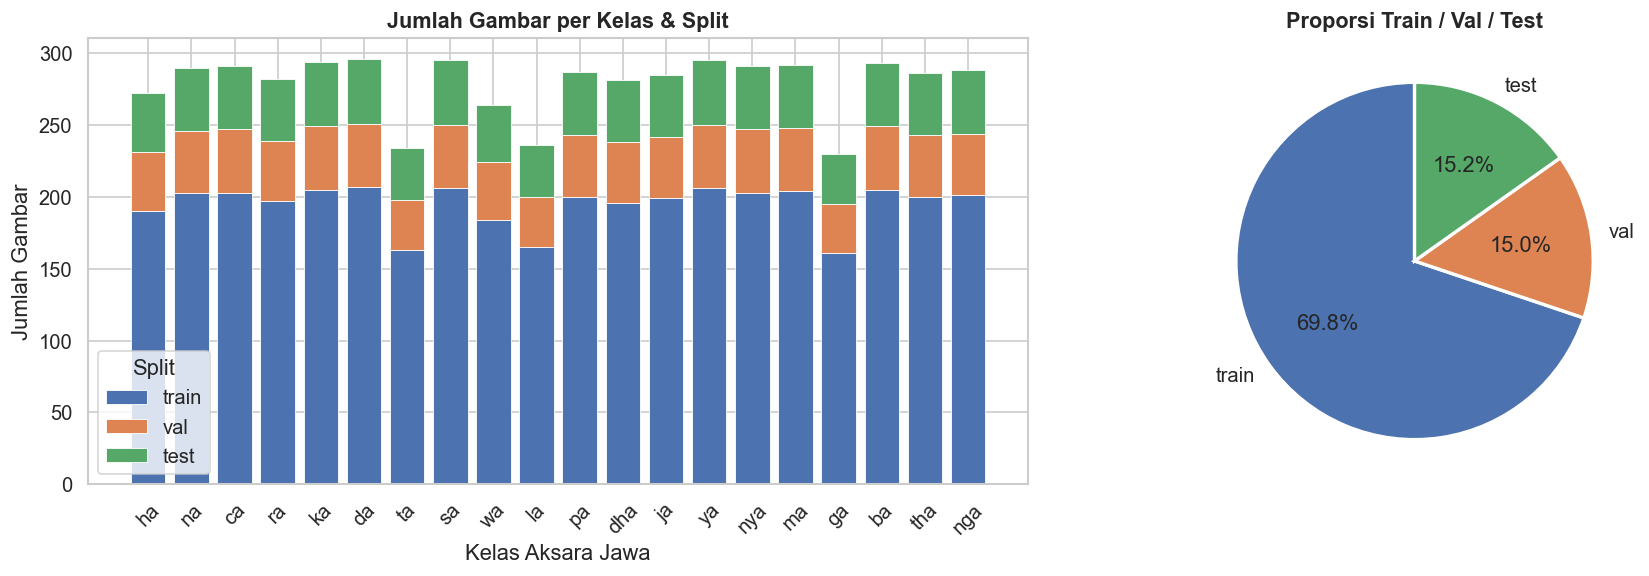

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Left: Stacked bar per class ──────────────────────────────────────────
colors = {'train': '#4C72B0', 'val': '#DD8452', 'test': '#55A868'}
bottom = np.zeros(len(pivot))

for split in SPLITS:
    axes[0].bar(
        pivot.index,
        pivot[split].values,
        bottom=bottom,
        label=split,
        color=colors[split],
        edgecolor='white',
        linewidth=0.5,
    )
    bottom += pivot[split].values

axes[0].set_title('Jumlah Gambar per Kelas & Split', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Kelas Aksara Jawa')
axes[0].set_ylabel('Jumlah Gambar')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(title='Split')

# ── Right: Pie chart total split ─────────────────────────────────────────
split_totals = df['split'].value_counts().reindex(SPLITS)
axes[1].pie(
    split_totals.values,
    labels=split_totals.index,
    autopct='%1.1f%%',
    colors=[colors[s] for s in split_totals.index],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
)
axes[1].set_title('Proporsi Train / Val / Test', fontsize=13, fontweight='bold')

plt.tight_layout()
out = EDA_OUT / 'eda_01_class_distribution.png'
plt.savefig(out, bbox_inches='tight')
print(f'Saved → {out}')
plt.show()

## 3. Analisis Class Imbalance

Max samples (train): 207 — class 'da'
Min samples (train): 161 — class 'ga'
Imbalance ratio    : 1.29x

Imbalance dalam batas wajar (<3x).
Saved → eda_results\eda_02_class_imbalance.png


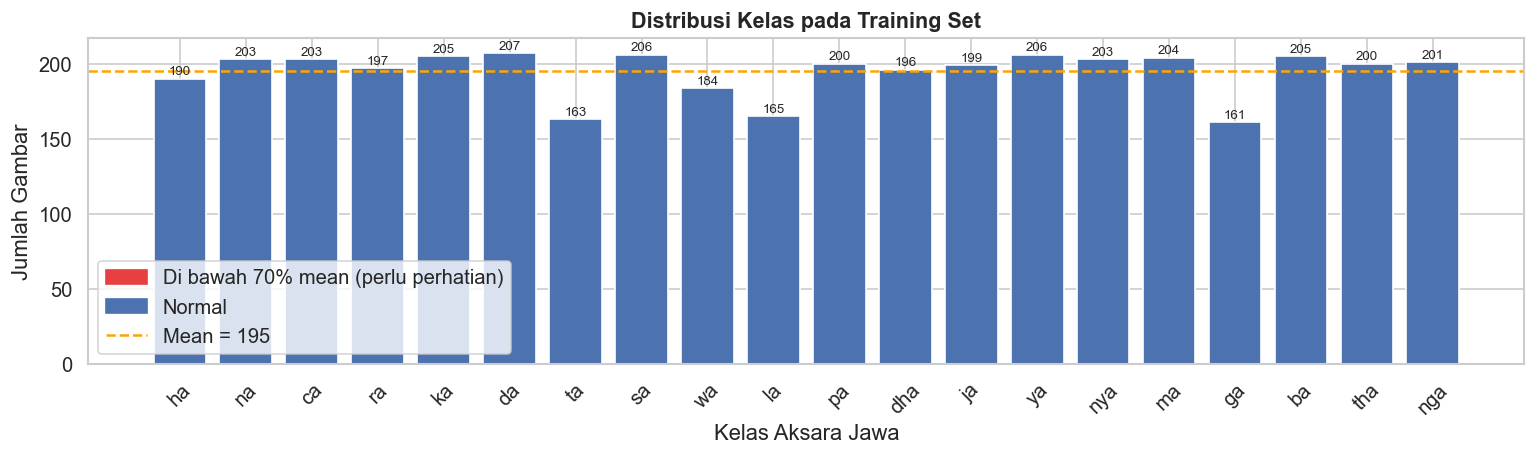

In [6]:
train_counts = pivot['train']
imbalance_ratio = train_counts.max() / train_counts.replace(0, np.nan).min()

print(f"Max samples (train): {train_counts.max()} — class '{train_counts.idxmax()}'")
print(f"Min samples (train): {train_counts.min()} — class '{train_counts.idxmin()}'")
print(f"Imbalance ratio    : {imbalance_ratio:.2f}x")

if imbalance_ratio > 3:
    print("\nImbalance > 3x detected.")
    print("   Mitigasi: class_weight='balanced' atau augmentasi kelas minoritas.")
else:
    print("\nImbalance dalam batas wajar (<3x).")

# Visualize
fig, ax = plt.subplots(figsize=(13, 4))
bar_colors = [
    '#E84040' if v < train_counts.mean() * 0.7 else '#4C72B0'
    for v in train_counts.values
]
bars = ax.bar(train_counts.index, train_counts.values, color=bar_colors, edgecolor='white')
ax.axhline(train_counts.mean(), color='orange', linestyle='--', linewidth=1.5, label=f'Mean = {train_counts.mean():.0f}')
ax.set_title('Distribusi Kelas pada Training Set', fontsize=13, fontweight='bold')
ax.set_xlabel('Kelas Aksara Jawa')
ax.set_ylabel('Jumlah Gambar')
ax.tick_params(axis='x', rotation=45)
ax.legend()

for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        str(int(bar.get_height())),
        ha='center', va='bottom', fontsize=8
    )

low_patch  = mpatches.Patch(color='#E84040', label='Di bawah 70% mean (perlu perhatian)')
high_patch = mpatches.Patch(color='#4C72B0', label='Normal')
ax.legend(handles=[low_patch, high_patch, ax.lines[0]])

plt.tight_layout()
out = EDA_OUT / 'eda_02_class_imbalance.png'
plt.savefig(out, bbox_inches='tight')
print(f'Saved → {out}')
plt.show()

## 4. Analisis Dimensi Gambar

In [7]:
# Sample dari train set untuk efisiensi (max 1000 gambar)
sample_df = df[df['split'] == 'train'].sample(
    min(1000, len(df[df['split'] == 'train'])),
    random_state=42
)

dims = []
for _, row in tqdm(sample_df.iterrows(), total=len(sample_df), desc='Reading image dims'):
    try:
        with Image.open(row['path']) as img:
            w, h = img.size
            mode = img.mode
            dims.append({'width': w, 'height': h, 'mode': mode, 'class': row['class']})
    except Exception:
        pass

dim_df = pd.DataFrame(dims)
print('Image dimension stats:')
print(dim_df[['width', 'height']].describe().round(1))
print(f"\nColor modes: {dim_df['mode'].value_counts().to_dict()}")

Reading image dims:   0%|          | 0/1000 [00:00<?, ?it/s]

Image dimension stats:
        width  height
count  1000.0  1000.0
mean    348.2   291.7
std     116.2    82.4
min      43.0    22.0
25%     306.0   265.0
50%     345.0   300.0
75%     416.2   329.0
max     635.0   539.0

Color modes: {'RGB': 716, 'RGBA': 284}


Saved → eda_results\eda_03_image_dimensions.png


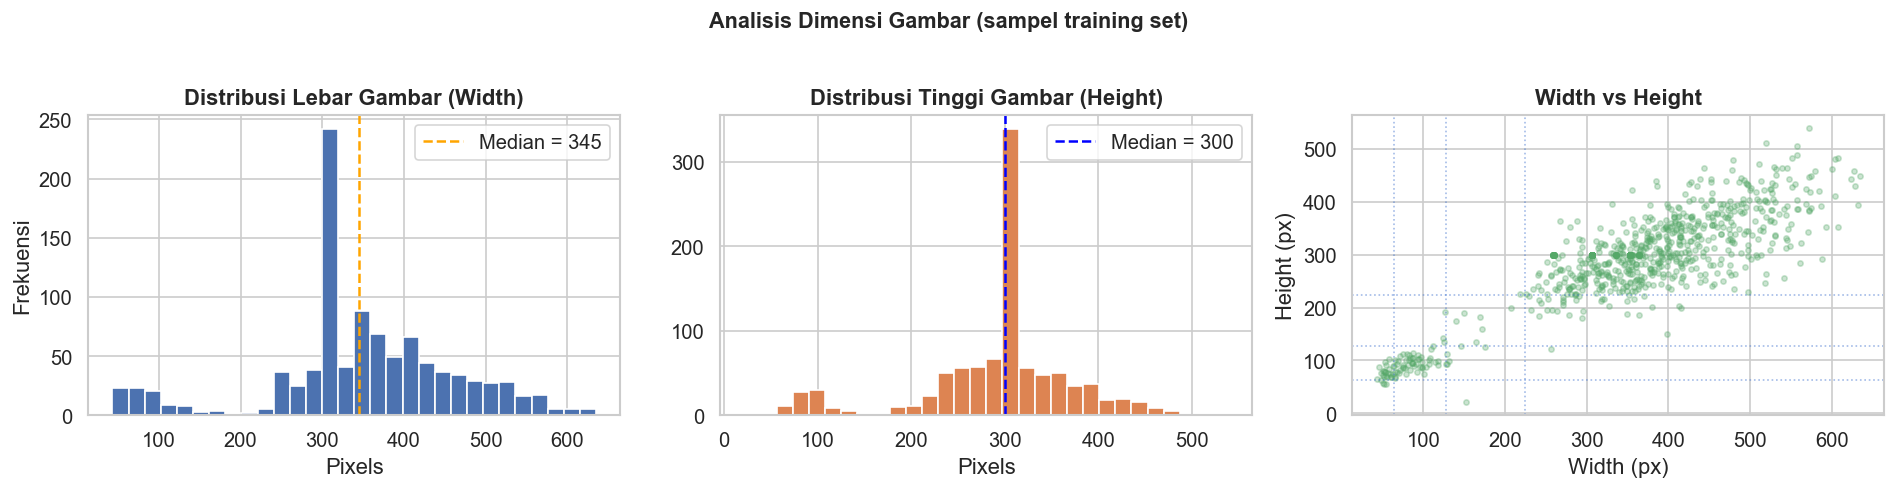


Median dimensi: 345 × 300 px
Rekomendasi resize target:
  64×64 px — lightweight, cepat
  128×128 px — lightweight, cepat
  224×224 px — standard CNN input (ImageNet)


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Width distribution
axes[0].hist(dim_df['width'], bins=30, color='#4C72B0', edgecolor='white')
axes[0].axvline(dim_df['width'].median(), color='orange', linestyle='--',
                label=f"Median = {dim_df['width'].median():.0f}")
axes[0].set_title('Distribusi Lebar Gambar (Width)', fontweight='bold')
axes[0].set_xlabel('Pixels')
axes[0].set_ylabel('Frekuensi')
axes[0].legend()

# Height distribution
axes[1].hist(dim_df['height'], bins=30, color='#DD8452', edgecolor='white')
axes[1].axvline(dim_df['height'].median(), color='blue', linestyle='--',
                label=f"Median = {dim_df['height'].median():.0f}")
axes[1].set_title('Distribusi Tinggi Gambar (Height)', fontweight='bold')
axes[1].set_xlabel('Pixels')
axes[1].legend()

# Width vs Height scatter
axes[2].scatter(dim_df['width'], dim_df['height'], alpha=0.3, s=10, color='#55A868')
axes[2].set_title('Width vs Height', fontweight='bold')
axes[2].set_xlabel('Width (px)')
axes[2].set_ylabel('Height (px)')

for target in [64, 128, 224]:
    axes[2].axvline(target, linestyle=':', alpha=0.5, linewidth=1)
    axes[2].axhline(target, linestyle=':', alpha=0.5, linewidth=1)

plt.suptitle('Analisis Dimensi Gambar (sampel training set)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
out = EDA_OUT / 'eda_03_image_dimensions.png'
plt.savefig(out, bbox_inches='tight')
print(f'Saved → {out}')
plt.show()

med_w, med_h = int(dim_df['width'].median()), int(dim_df['height'].median())
print(f"\nMedian dimensi: {med_w} × {med_h} px")
print("Rekomendasi resize target:")
for t in [64, 128, 224]:
    print(f"  {t}×{t} px — {'standard CNN input (ImageNet)' if t == 224 else 'lightweight, cepat'}")

## 5. Sample Visual per Kelas

Saved → eda_results\eda_04_samples_per_class.png


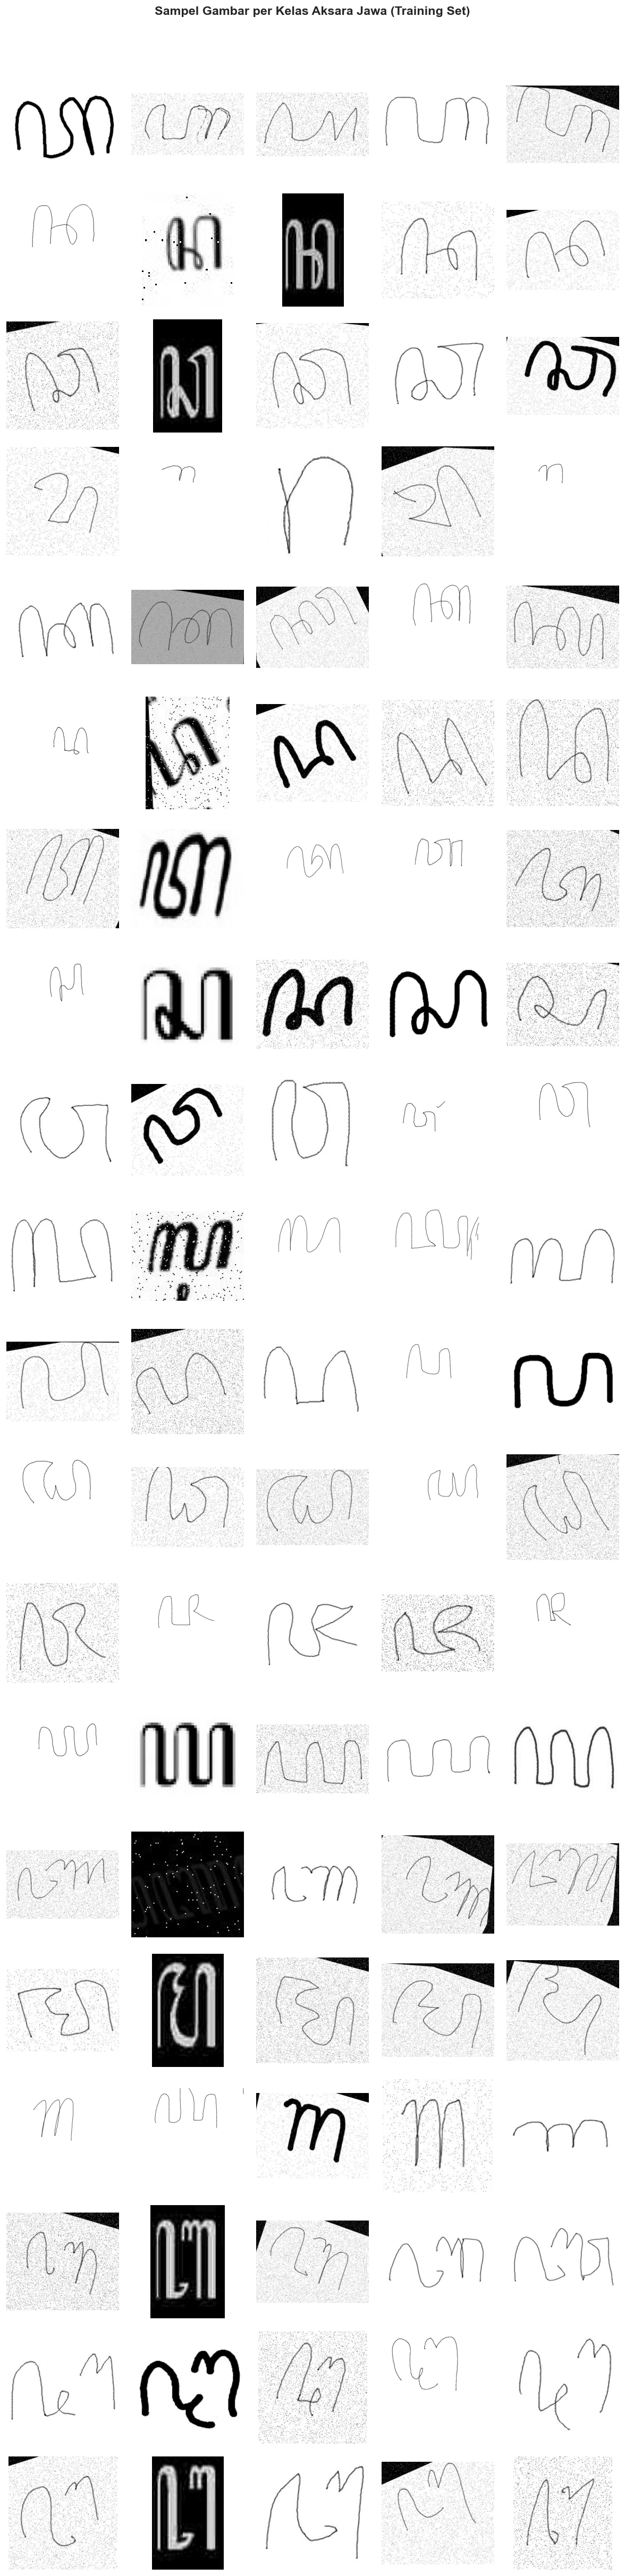

In [9]:
n_samples_per_class = 5
n_classes = len(CLASSES)

fig, axes = plt.subplots(
    n_classes, n_samples_per_class,
    figsize=(n_samples_per_class * 2, n_classes * 2)
)

train_df = df[df['split'] == 'train']

for row_idx, cls in enumerate(CLASSES):
    cls_paths = train_df[train_df['class'] == cls]['path'].tolist()
    sampled   = cls_paths[:n_samples_per_class] if len(cls_paths) >= n_samples_per_class else cls_paths

    for col_idx in range(n_samples_per_class):
        ax = axes[row_idx][col_idx]
        ax.axis('off')

        if col_idx < len(sampled):
            try:
                img = Image.open(sampled[col_idx]).convert('L')
                ax.imshow(img, cmap='gray', aspect='equal')
            except Exception:
                ax.text(0.5, 0.5, 'error', ha='center', va='center')

        if col_idx == 0:
            ax.set_ylabel(cls, fontsize=10, fontweight='bold', rotation=0,
                         labelpad=30, va='center')

fig.suptitle('Sampel Gambar per Kelas Aksara Jawa (Training Set)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
out = EDA_OUT / 'eda_04_samples_per_class.png'
plt.savefig(out, bbox_inches='tight')
print(f'Saved → {out}')
plt.show()

## 6. Analisis Intensitas Piksel (Mean & Std per Kelas)

In [10]:
TARGET_SIZE = (64, 64)  # Untuk analisis intensitas, tidak perlu besar

pixel_stats = defaultdict(lambda: {'means': [], 'stds': []})

for _, row in tqdm(train_df.iterrows(), total=len(train_df), desc='Computing pixel stats'):
    try:
        img = Image.open(row['path']).convert('L').resize(TARGET_SIZE)
        arr = np.array(img, dtype=np.float32) / 255.0
        pixel_stats[row['class']]['means'].append(arr.mean())
        pixel_stats[row['class']]['stds'].append(arr.std())
    except Exception:
        pass

# Build summary df
stat_rows = []
for cls in CLASSES:
    if cls in pixel_stats:
        means = pixel_stats[cls]['means']
        stds  = pixel_stats[cls]['stds']
        stat_rows.append({
            'class':     cls,
            'mean_intensity': np.mean(means),
            'std_intensity':  np.mean(stds),
            'std_of_mean':    np.std(means),
        })

stat_df = pd.DataFrame(stat_rows).set_index('class')
print('Pixel intensity statistics per class:')
print(stat_df.round(3))

Computing pixel stats:   0%|          | 0/3898 [00:00<?, ?it/s]

Pixel intensity statistics per class:
       mean_intensity  std_intensity  std_of_mean
class                                            
ha              0.902          0.138        0.153
na              0.903          0.124        0.167
ca              0.897          0.135        0.163
ra              0.930          0.108        0.129
ka              0.896          0.127        0.169
da              0.897          0.126        0.171
ta              0.913          0.119        0.147
sa              0.902          0.127        0.159
wa              0.917          0.115        0.152
la              0.912          0.113        0.157
pa              0.918          0.114        0.146
dha             0.921          0.121        0.123
ja              0.908          0.130        0.149
ya              0.906          0.119        0.160
nya             0.889          0.148        0.161
ma              0.905          0.125        0.158
ga              0.909          0.123        0.161
ba          

Saved → eda_results\eda_05_pixel_intensity.png


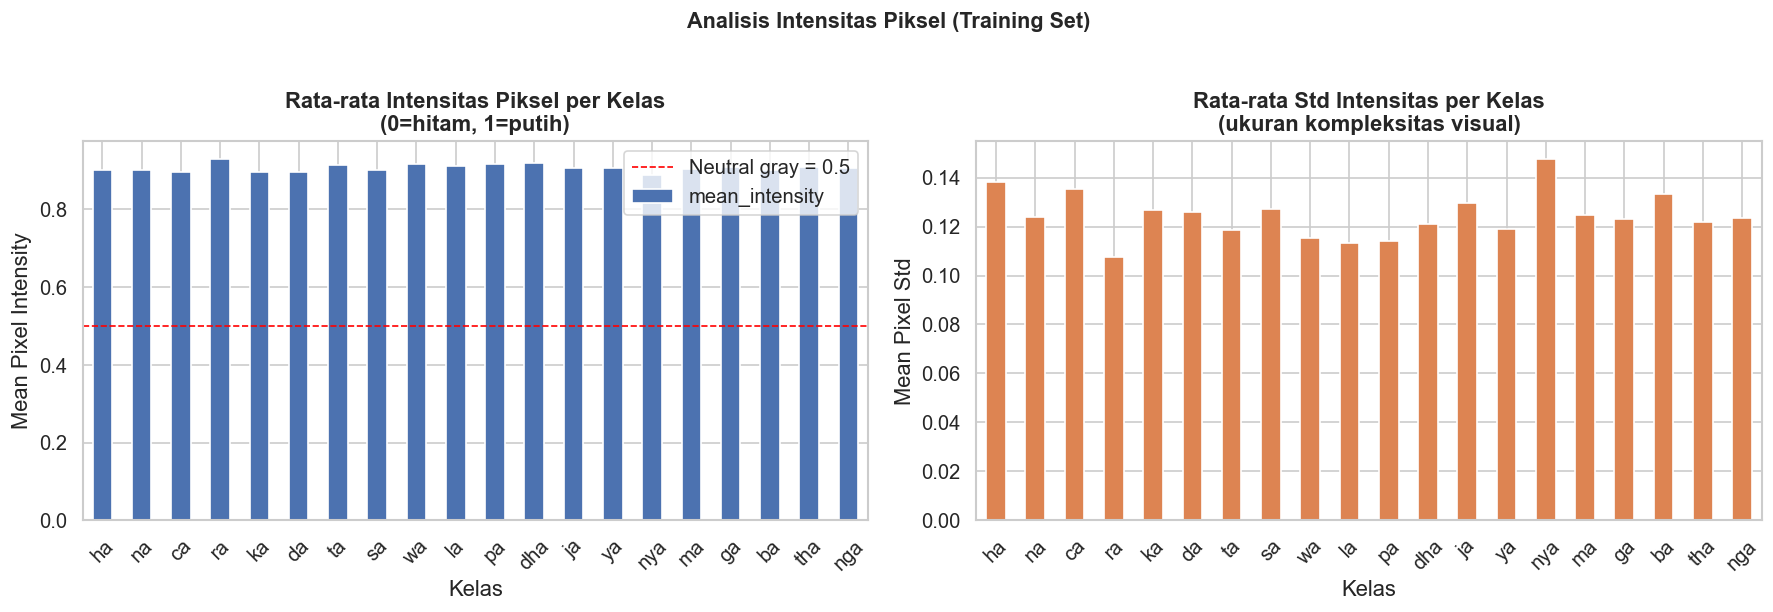


Kelas paling kompleks secara visual (std tinggi): 'nya'
Kelas paling sederhana secara visual (std rendah): 'ra'

Note: Kelas dengan std rendah cenderung lebih mudah diklasifikasikan oleh CNN.


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

stat_df['mean_intensity'].reindex(CLASSES).plot(
    kind='bar', ax=axes[0], color='#4C72B0', edgecolor='white'
)
axes[0].axhline(0.5, color='red', linestyle='--', linewidth=1, label='Neutral gray = 0.5')
axes[0].set_title('Rata-rata Intensitas Piksel per Kelas\n(0=hitam, 1=putih)', fontweight='bold')
axes[0].set_xlabel('Kelas')
axes[0].set_ylabel('Mean Pixel Intensity')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend()

stat_df['std_intensity'].reindex(CLASSES).plot(
    kind='bar', ax=axes[1], color='#DD8452', edgecolor='white'
)
axes[1].set_title('Rata-rata Std Intensitas per Kelas\n(ukuran kompleksitas visual)', fontweight='bold')
axes[1].set_xlabel('Kelas')
axes[1].set_ylabel('Mean Pixel Std')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Analisis Intensitas Piksel (Training Set)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
out = EDA_OUT / 'eda_05_pixel_intensity.png'
plt.savefig(out, bbox_inches='tight')
print(f'Saved → {out}')
plt.show()

high_contrast = stat_df['std_intensity'].idxmax()
low_contrast  = stat_df['std_intensity'].idxmin()
print(f"\nKelas paling kompleks secara visual (std tinggi): '{high_contrast}'")
print(f"Kelas paling sederhana secara visual (std rendah): '{low_contrast}'")
print("\nNote: Kelas dengan std rendah cenderung lebih mudah diklasifikasikan oleh CNN.")

## 7. Distribusi Format File & Potensi Masalah

Saved → eda_results\eda_06_format_heatmap.png


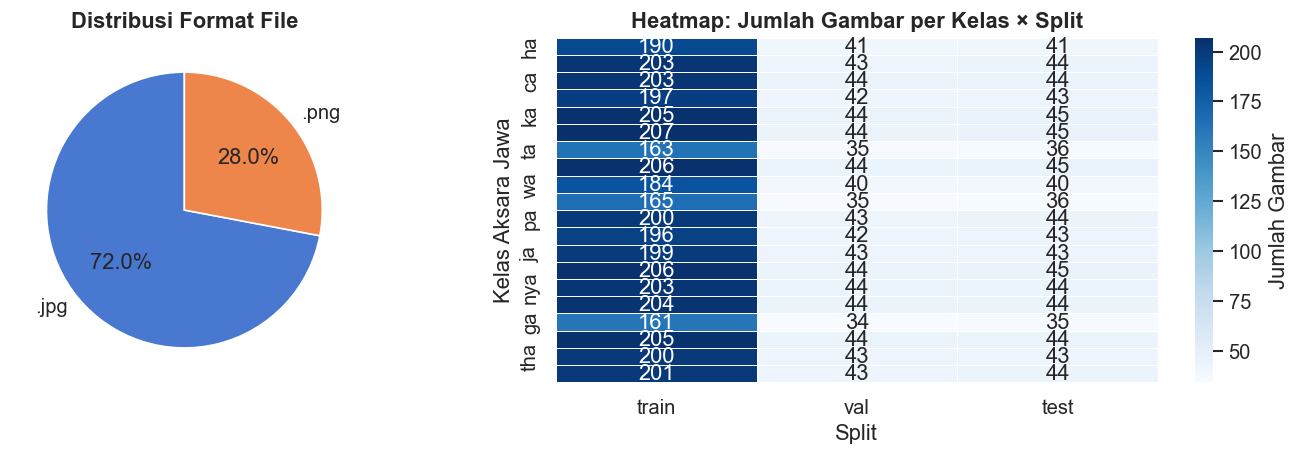

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# File extension distribution
ext_counts = df['ext'].value_counts()
axes[0].pie(
    ext_counts.values,
    labels=ext_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white'},
)
axes[0].set_title('Distribusi Format File', fontweight='bold')

# Images per class per split heatmap
heatmap_data = (
    df.groupby(['class', 'split'])
    .size()
    .unstack(fill_value=0)
    .reindex(index=CLASSES, columns=SPLITS, fill_value=0)
)

sns.heatmap(
    heatmap_data,
    ax=axes[1],
    annot=True,
    fmt='d',
    cmap='Blues',
    linewidths=0.5,
    cbar_kws={'label': 'Jumlah Gambar'},
)
axes[1].set_title('Heatmap: Jumlah Gambar per Kelas × Split', fontweight='bold')
axes[1].set_xlabel('Split')
axes[1].set_ylabel('Kelas Aksara Jawa')

plt.tight_layout()
out = EDA_OUT / 'eda_06_format_heatmap.png'
plt.savefig(out, bbox_inches='tight')
print(f'Saved → {out}')
plt.show()

## 8. Dataset Global Mean & Std (Untuk Normalisasi CNN)

In [13]:
"""
Nilai ini WAJIB dihitung dari training set saja.
Jangan pakai ImageNet mean/std jika tidak menggunakan pretrained model.
Nilai ini dipakai di transforms.Normalize() saat training.
"""

all_means, all_stds = [], []

for _, row in tqdm(train_df.iterrows(), total=len(train_df), desc='Computing global stats'):
    try:
        img = Image.open(row['path']).convert('RGB').resize((128, 128))
        arr = np.array(img, dtype=np.float32) / 255.0  # shape: (128, 128, 3)
        all_means.append(arr.mean(axis=(0, 1)))         # per-channel mean
        all_stds.append(arr.std(axis=(0, 1)))           # per-channel std
    except Exception:
        pass

global_mean = np.array(all_means).mean(axis=0)
global_std  = np.array(all_stds).mean(axis=0)

print('─' * 40)
print('NILAI NORMALISASI UNTUK PYTORCH')
print('─' * 40)
print(f'mean = ({global_mean[0]:.4f}, {global_mean[1]:.4f}, {global_mean[2]:.4f})')
print(f'std  = ({global_std[0]:.4f},  {global_std[1]:.4f},  {global_std[2]:.4f})')
print('─' * 40)
print()
print('Paste ini ke training script:')
print(f"""
transforms.Normalize(
    mean=[{global_mean[0]:.4f}, {global_mean[1]:.4f}, {global_mean[2]:.4f}],
    std= [{global_std[0]:.4f},  {global_std[1]:.4f},  {global_std[2]:.4f}],
)
""")

Computing global stats:   0%|          | 0/3898 [00:00<?, ?it/s]

────────────────────────────────────────
NILAI NORMALISASI UNTUK PYTORCH
────────────────────────────────────────
mean = (0.9071, 0.9067, 0.9062)
std  = (0.1390,  0.1392,  0.1388)
────────────────────────────────────────

Paste ini ke training script:

transforms.Normalize(
    mean=[0.9071, 0.9067, 0.9062],
    std= [0.1390,  0.1392,  0.1388],
)



In [14]:
print('=' * 50)
print('EDA selesai. Semua gambar tersimpan di:')
print(f'  {EDA_OUT.resolve()}')
print()
saved = sorted(EDA_OUT.glob('eda_*.png'))
for f in saved:
    size_kb = f.stat().st_size / 1024
    print(f'  {f.name:<40} ({size_kb:.1f} KB)')
print(f'\nTotal: {len(saved)} file')

EDA selesai. Semua gambar tersimpan di:
  C:\KULIAH\SEMESTER 4\PEMBELAJARAN MESIN\KlasifikasiHanacaraka\eda_results

  eda_01_class_distribution.png            (67.4 KB)
  eda_02_class_imbalance.png               (50.5 KB)
  eda_03_image_dimensions.png              (96.8 KB)
  eda_04_samples_per_class.png             (2367.0 KB)
  eda_05_pixel_intensity.png               (69.1 KB)
  eda_06_format_heatmap.png                (89.0 KB)

Total: 6 file
